In [1]:
import numpy as np
from matplotlib import pyplot as plt
from os import listdir
from os.path import join
from scipy.io import wavfile
from librosa.feature import melspectrogram
from librosa import power_to_db,display
import random
from sklearn.model_selection import KFold
from joblib import dump, load 
import pandas as pd
from sklearn.ensemble import RandomForestClassifier as RFC
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn import svm
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from extracter import *
from fitting_model import *

C:\Users\Phi Hung Nguyen\anaconda3\Lib\site-packages\paramiko\pkey.py:82: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "cipher": algorithms.TripleDES,
C:\Users\Phi Hung Nguyen\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.Blowfish and will be removed from this module in 45.0.0.
  "class": algorithms.Blowfish,
C:\Users\Phi Hung Nguyen\anaconda3\Lib\site-packages\paramiko\transport.py:243: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "class": algorithms.TripleDES,


We have stored this and distribute it into:
- 5_fold_#_5speakers_36fts: the spectrogram is decomposed into 6x6 and storing the mean and std. We generate 5 folds for testing and training.
- 5_fold_#_5speakers_349ts: the spectrogram is decomposed into 7x7 and storing the mean and std. We generate 5 folds for testing and training.

In [3]:
"""
Storing 
"""
files = "recordings/" # inside recordings are a set of files
ds_files = listdir(files)[1:] # ignoring .ipynb file
random.seed(43)
#random.shuffle(ds_files)
repetition = 10
Audios = []
y = []

names = ["george", "jackson", "theo", "lucas", "nicolas"] #we indicate the five people to collect data
digits = [str(i) for i in range(10)] # we indicate the ten digits

person_digit_counts = { # store inside a dicitonary
    name + digit: 0
    for name in names
    for digit in digits
}

for file in ds_files:
    label = str(file.split("_")[0])
    person = str(file.split("_")[1])
    if person not in names:
        continue
    key = person + label
    if person_digit_counts[key] >= repetition: # store ten for each digit for each people
        continue
    rate, data = wavfile.read(join(files, file)) # we read audio amplitude at rate 8000hz for the full audio
    Audios.append(data.astype(np.float16))
    y.append(int(label))
    person_digit_counts[key] += 1

print("Distribution: ", person_digit_counts)
print("Total utterance of each digit: ", np.unique(y, return_counts=True))
print("Amount of collected utterances: ", len(Audios))

Distribution:  {'george0': 10, 'george1': 10, 'george2': 10, 'george3': 10, 'george4': 10, 'george5': 10, 'george6': 10, 'george7': 10, 'george8': 10, 'george9': 10, 'jackson0': 10, 'jackson1': 10, 'jackson2': 10, 'jackson3': 10, 'jackson4': 10, 'jackson5': 10, 'jackson6': 10, 'jackson7': 10, 'jackson8': 10, 'jackson9': 10, 'theo0': 10, 'theo1': 10, 'theo2': 10, 'theo3': 10, 'theo4': 10, 'theo5': 10, 'theo6': 10, 'theo7': 10, 'theo8': 10, 'theo9': 10, 'lucas0': 10, 'lucas1': 10, 'lucas2': 10, 'lucas3': 10, 'lucas4': 10, 'lucas5': 10, 'lucas6': 10, 'lucas7': 10, 'lucas8': 10, 'lucas9': 10, 'nicolas0': 10, 'nicolas1': 10, 'nicolas2': 10, 'nicolas3': 10, 'nicolas4': 10, 'nicolas5': 10, 'nicolas6': 10, 'nicolas7': 10, 'nicolas8': 10, 'nicolas9': 10}
Total utterance of each digit:  (array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]), array([50, 50, 50, 50, 50, 50, 50, 50, 50, 50], dtype=int64))
Amount of collected utterances:  500


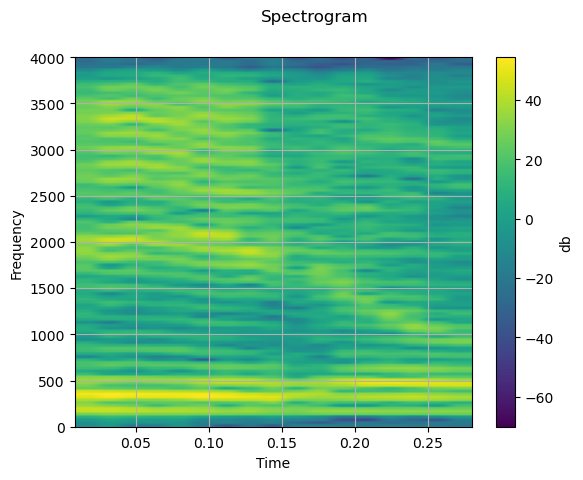

In [4]:
# Plot the spectrogram of power on log scale
powerSpectrum, frequenciesFound, time, imageAxis = plt.specgram(Audios[0], Fs=rate, scale = "dB")

# frequenciesFound gives all the found frequencies
# powerSpectrum gives the strength of a specific frequency for all time. powerSpectrum[index] where index corresponds to frequency
cbar = plt.gcf().colorbar(imageAxis)
cbar.set_label('db')
plt.grid()
plt.suptitle("Spectrogram")
plt.xlabel('Time')
plt.ylabel('Frequency')
plt.show()   

In [5]:
print(f"Power spectrum at the time {time[0]}: ", powerSpectrum[0])
print("All frequencies found across the audio: ", frequenciesFound)

Power spectrum at the time 0.016:  [9.90470138e-02 4.53831627e-01 1.24923096e-02 2.51074056e-02
 2.56672659e-01 1.52421612e-02 2.96300868e-04 7.73804380e-03
 3.85733481e-04 2.07172817e-02 3.22930442e-02 1.86006309e-02
 1.17846289e-02 2.67129986e-02 1.66226121e-02 1.32305065e-02
 7.21332294e-03]
All frequencies found across the audio:  [   0.     31.25   62.5    93.75  125.    156.25  187.5   218.75  250.
  281.25  312.5   343.75  375.    406.25  437.5   468.75  500.    531.25
  562.5   593.75  625.    656.25  687.5   718.75  750.    781.25  812.5
  843.75  875.    906.25  937.5   968.75 1000.   1031.25 1062.5  1093.75
 1125.   1156.25 1187.5  1218.75 1250.   1281.25 1312.5  1343.75 1375.
 1406.25 1437.5  1468.75 1500.   1531.25 1562.5  1593.75 1625.   1656.25
 1687.5  1718.75 1750.   1781.25 1812.5  1843.75 1875.   1906.25 1937.5
 1968.75 2000.   2031.25 2062.5  2093.75 2125.   2156.25 2187.5  2218.75
 2250.   2281.25 2312.5  2343.75 2375.   2406.25 2437.5  2468.75 2500.
 2531.25 2562.

To analyze our system, we perform melspectrogram analysis.

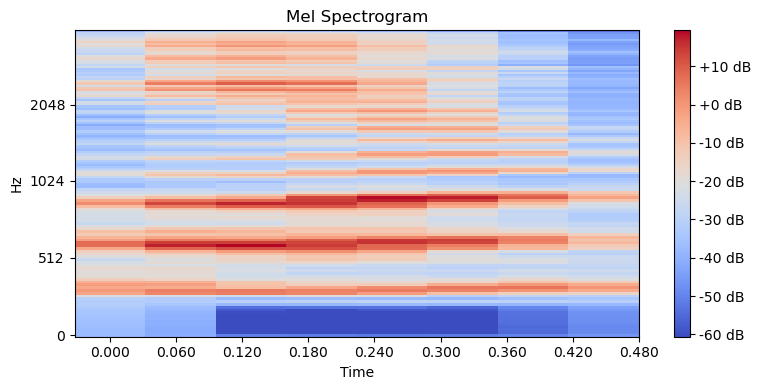

(128, 8)

In [7]:
mel = melspectrogram(y=Audios[3], n_fft= len(Audios[0]))
mel_db = power_to_db(mel, ref=np.mean)
plt.figure(figsize=(8, 4))
display.specshow(
    mel_db,
    sr=rate,
    x_axis="time",
    y_axis="mel"
)
plt.colorbar(format="%+2.0f dB")
plt.title("Mel Spectrogram")
plt.tight_layout()
plt.show()
mel_db.shape

In [8]:
def ft_mean_std(Audios, n, f_s = 8000):
    """
    For each melspectrogram audio, we decompose it into an nxn block. For each block, we extract the mean and std. 
    Parameters:
        Audios: a set of audios 
        n: splitting nxn spectogram
    Returns: A 2-d numpy array - 500x(2*n*n) where 2 indicates mean and std for each block 
    and each melspectrogram has n*n blocks
    """
    Audios_sp = [] #feature matrix
    for Audio in Audios: # for each audio
        sp = power_to_db(melspectrogram(y=Audio, n_fft=len(Audio)), ref=np.mean) # perform melspectrogram
        Audio_sp = [] #current feature set
        # split the rows
        for v_split in np.array_split(sp, n, axis = 0): # split this spectrogram into n rows
            # split the columns
            for h_split in np.array_split(v_split, n, axis = 1): # split this spectrogram into n columns
                if h_split.size == 0: #happens when number of columns < n
                    m = np.median(v_split).__round__(4)
                    sd = np.std(v_split).__round__(4)
                else:
                    m = np.mean(h_split).__round__(4)
                    sd = np.std(h_split).__round__(4)
                Audio_sp.extend([m,sd]) # we add [mean,std,mean,std,...] for the current spectrogram
        Audios_sp.append(Audio_sp) # We perform the same for all the audios
    return np.array(Audios_sp)

In [9]:
# turn audios into a 2-d numpy array - 500x(2*n*n)
n = 7
X_ft = ft_mean_std(Audios, n)
# associate the vector of features with its target 
y_bar = []
for i in y:
    y_bar += [i]*n*n # we have n*n means and stds to predict a single target
y_bar = np.array(y_bar)
# Reshape into:
# num_samples × n blocks × 2 values: [mean, std]
X_blocks = X_ft.reshape(len(X_ft), n*n, 2)
# Extract means and stds separately into two vectors
X_mean = X_blocks[:, :, 0].reshape(-1)
X_std = X_blocks[:, :, 1].reshape(-1)
# Norm
max_mean = 0
min_mean = 0
for i in X_mean:
    if i >= max_mean:
        max_mean = i
    if i <= min_mean:
        min_mean = i
max_std = 0
min_std = 0
for i in X_std:
    if i >= max_std:
        max_std = i
    if i <= min_std:
        min_std = i
        
difference_mean = max_mean - min_mean
difference_std = max_std - min_std
X_mean = ((X_mean-min_mean)/difference_mean)
X_std = ((X_std-min_std)/difference_std)

"""
X_new = []
for i in range(len(X_mean)):
    X_new.append(X_mean[i])
    X_new.append(X_std[i])

X_new = np.array(X_new)"""
print("Masked Target: ",y_bar)
print("Mean inputs: ", X_mean)
print("Std inputs: ", X_std)

Masked Target:  [0 0 0 ... 9 9 9]
Mean inputs:  [0.66026324 0.6208249  0.3887811  ... 0.54063797 0.5316898  0.50364804]
Std inputs:  [0.3164562  0.3904954  0.659128   ... 0.23440062 0.22301927 0.19718124]


By performing this analysis, we store them into joblib files. From now on, we extract these values from joblib files. We analyze performance with methods SVM, RFC, and we compare these with our small quantum system.

In [35]:
from sklearn.metrics import precision_recall_fscore_support, classification_report
from sklearn.model_selection import train_test_split
import numpy as np
scores = {}
errors = {}
for n in [3, 4, 5, 6, 7]:
    X_ft = ft_mean_std(Audios, n)
    X_train, X_test, y_train, y_test = train_test_split(X_ft, y, test_size=0.20)
    score = []
    errors[n] = {}
    for model in models:
        clf = models[model]
        clf.fit(X_train, y_train)
        prediction = clf.predict(X_test)
        real_answer = y_test
        print("Model:", model)
        print("Prediction:", prediction)
        print("Real answer:", real_answer)
        substitution = 0
        for i in range(len(real_answer)):
            if real_answer[i] != prediction[i]:
                substitution += 1
        WER = substitution / len(real_answer)
        errors[n][model] = WER
        score.append((model, WER))
        print("Substitution:", substitution)
        print("WER:", WER)
    scores[n] = score

Model: rfc
Prediction: [5 3 4 0 7 9 5 0 6 7 4 1 7 4 5 3 7 0 9 8 1 9 9 0 7 8 2 2 4 3 5 6 5 3 0 3 9
 8 7 8 0 4 4 8 5 5 6 9 9 6 0 0 0 5 5 1 6 3 1 5 6 8 4 2 9 2 2 6 0 5 2 7 4 8
 7 0 5 8 7 6 5 8 6 8 9 5 4 6 2 1 1 4 4 5 0 8 0 3 8 6]
Real answer: [5, 3, 4, 0, 7, 9, 5, 0, 6, 7, 4, 1, 7, 4, 5, 3, 7, 0, 9, 6, 9, 1, 9, 0, 7, 8, 2, 2, 4, 3, 5, 6, 5, 3, 0, 3, 9, 8, 7, 8, 0, 9, 1, 8, 5, 5, 6, 9, 7, 6, 0, 0, 0, 5, 5, 1, 6, 3, 1, 5, 6, 8, 4, 2, 7, 2, 2, 6, 0, 5, 2, 7, 4, 3, 7, 0, 5, 6, 7, 6, 5, 8, 6, 8, 9, 5, 4, 6, 2, 1, 9, 4, 4, 5, 0, 8, 0, 3, 8, 6]
Substitution: 10
WER: 0.1
Model: svm
Prediction: [5 3 4 0 7 7 5 0 3 7 4 1 7 4 9 3 7 0 9 6 1 1 9 0 7 8 2 2 4 3 5 6 5 3 0 3 9
 8 7 8 0 1 1 8 5 5 6 5 7 6 0 0 0 5 5 1 6 3 1 1 6 8 4 2 7 2 2 6 0 5 2 7 4 3
 7 0 5 6 7 3 5 8 6 8 9 5 4 6 2 1 7 4 4 5 3 8 0 3 8 6]
Real answer: [5, 3, 4, 0, 7, 9, 5, 0, 6, 7, 4, 1, 7, 4, 5, 3, 7, 0, 9, 6, 9, 1, 9, 0, 7, 8, 2, 2, 4, 3, 5, 6, 5, 3, 0, 3, 9, 8, 7, 8, 0, 9, 1, 8, 5, 5, 6, 9, 7, 6, 0, 0, 0, 5, 5, 1, 6, 3, 1, 5, 6, 8, 4, 2, 

In [37]:
errors

{3: {'rfc': 0.1, 'svm': 0.1},
 4: {'rfc': 0.13, 'svm': 0.1},
 5: {'rfc': 0.12, 'svm': 0.06},
 6: {'rfc': 0.11, 'svm': 0.06},
 7: {'rfc': 0.07, 'svm': 0.07}}

In [39]:
model_stats = {}
for model in models:
    model_errors = []
    for n in errors:
        model_errors.append(errors[n][model])
    model_errors = np.array(model_errors, dtype=float)
    model_stats[model] = {
        "mean_WER": np.mean(model_errors),
        "std_WER": np.std(model_errors, ddof=1),
        "all_WER": model_errors
    }

print(model_stats)

{'rfc': {'mean_WER': 0.10600000000000001, 'std_WER': 0.023021728866442673, 'all_WER': array([0.1 , 0.13, 0.12, 0.11, 0.07])}, 'svm': {'mean_WER': 0.078, 'std_WER': 0.0204939015319192, 'all_WER': array([0.1 , 0.1 , 0.06, 0.06, 0.07])}}
